Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib

Load Dataset

In [18]:
df = pd.read_csv("house_price_data.csv")
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


Drop Unnecessary Columns


In [19]:
df = df.drop(["date", "street", "city", "statezip", "country"], axis=1)
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
1,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
2,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0
3,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0
4,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979
4596,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009
4597,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0
4598,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0


EDA

In [20]:
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4600 non-null   float64
 1   bedrooms       4600 non-null   float64
 2   bathrooms      4600 non-null   float64
 3   sqft_living    4600 non-null   int64  
 4   sqft_lot       4600 non-null   int64  
 5   floors         4600 non-null   float64
 6   waterfront     4600 non-null   int64  
 7   view           4600 non-null   int64  
 8   condition      4600 non-null   int64  
 9   sqft_above     4600 non-null   int64  
 10  sqft_basement  4600 non-null   int64  
 11  yr_built       4600 non-null   int64  
 12  yr_renovated   4600 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 467.3 KB
None


In [21]:
print("\nDescription:")
print(df.describe())


Description:
              price     bedrooms    bathrooms   sqft_living      sqft_lot  \
count  4.600000e+03  4600.000000  4600.000000   4600.000000  4.600000e+03   
mean   5.519630e+05     3.400870     2.160815   2139.346957  1.485252e+04   
std    5.638347e+05     0.908848     0.783781    963.206916  3.588444e+04   
min    0.000000e+00     0.000000     0.000000    370.000000  6.380000e+02   
25%    3.228750e+05     3.000000     1.750000   1460.000000  5.000750e+03   
50%    4.609435e+05     3.000000     2.250000   1980.000000  7.683000e+03   
75%    6.549625e+05     4.000000     2.500000   2620.000000  1.100125e+04   
max    2.659000e+07     9.000000     8.000000  13540.000000  1.074218e+06   

            floors   waterfront         view    condition   sqft_above  \
count  4600.000000  4600.000000  4600.000000  4600.000000  4600.000000   
mean      1.512065     0.007174     0.240652     3.451739  1827.265435   
std       0.538288     0.084404     0.778405     0.677230   862.168977

In [22]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
dtype: int64


In [23]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')

Data Visualization

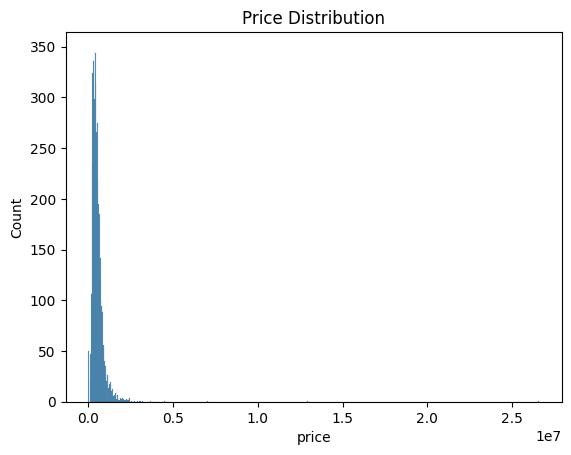

In [24]:
# Histogram
sns.histplot(df['price'])
plt.title("Price Distribution")
plt.show()

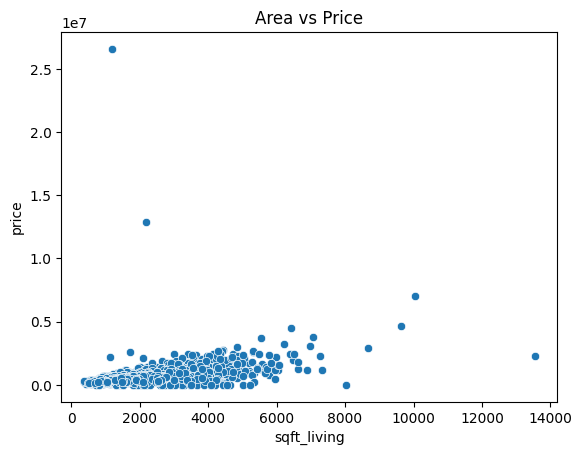

In [26]:
# Scatter Plot
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.title("Area vs Price")
plt.show()


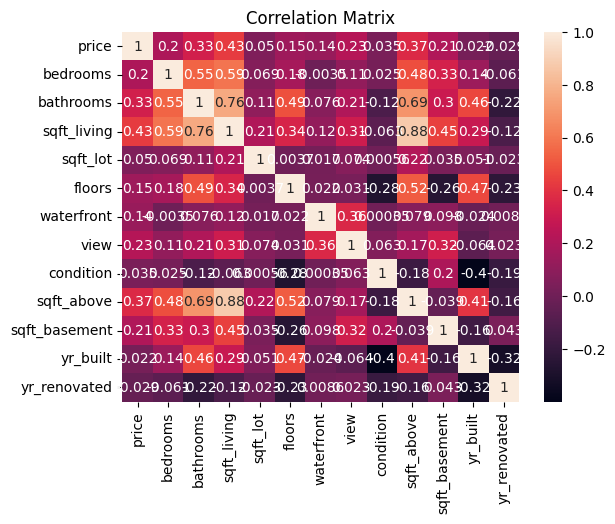

In [27]:
# Correlation Heatmap
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
Data Preprocessing

# Fill missing values
df = df.fillna(df.mean())

# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)

# Log transformation
df['price'] = np.log(df['price'])

# 6. Split Data
# ==============================
X = df.drop("price", axis=1)
y = df["price"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ==============================
# 7. Train Models
# ==============================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Gradient Boosting
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# ==============================
# 8. Evaluation
# ==============================

def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("Gradient Boosting", y_test, y_pred_gb)

# ==============================
# 9. Residual Analysis
# ==============================
residuals = y_test - y_pred_rf

sns.histplot(residuals)
plt.title("Residual Distribution (Random Forest)")
plt.show()

# ==============================
# 10. Save Best Model
# ==============================
joblib.dump(rf, "house_price_model.pkl")
print("\nModel saved as house_price_model.pkl")

# ==============================
# 11. Prediction Example
# ==============================
model = joblib.load("house_price_model.pkl")

sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

print("\nPredicted Price (log scale):", prediction)

# Convert back from log
actual_price = np.exp(prediction)
print("Predicted Price (actual):", actual_price)

Data Preprocessing

In [28]:
# Fill missing values
df = df.fillna(df.mean())


In [29]:
# Convert categorical to numeric
df = pd.get_dummies(df, drop_first=True)


In [45]:
# Remove invalid price values
df = df[df['price'] > 0]

# Log transformation
df['price'] = np.log(df['price'])

Feature Scaling

In [46]:
# Split Data
# ==============================
X = df.drop("price", axis=1)
y = df["price"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Model Training

In [47]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [48]:
# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [49]:
# Gradient Boosting
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

Model Evaluation

In [50]:
def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("Gradient Boosting", y_test, y_pred_gb)


Linear Regression
MAE: 0.008898457748488194
RMSE: 0.011668784876009879

Random Forest
MAE: 0.008587638947127173
RMSE: 0.011443068390164644

Gradient Boosting
MAE: 0.008370201523409936
RMSE: 0.011167362527977683


Residual Analysis

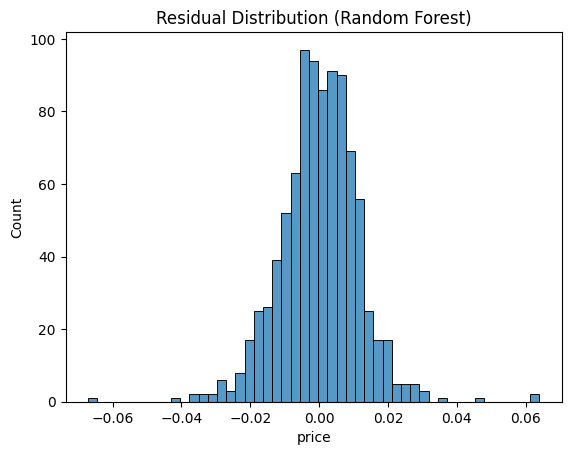

In [51]:
residuals = y_test - y_pred_rf

sns.histplot(residuals)
plt.title("Residual Distribution (Random Forest)")
plt.show()

Save Model

In [52]:
joblib.dump(rf, "house_price_model.pkl")
print("\nModel saved as house_price_model.pkl")


Model saved as house_price_model.pkl


Prediction Example

In [56]:
model = joblib.load("house_price_model.pkl")

sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

print("Predicted Price (log):", prediction)
print("Actual Price:", np.exp(prediction))

Predicted Price (log): [0.96873153]
Actual Price: [2.63460042]


In [54]:
model = joblib.load("house_price_model.pkl")

sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

print("\nPredicted Price (log scale):", prediction)

# Convert back from log
actual_price = np.exp(prediction)
print("Predicted Price (actual):", actual_price)


Predicted Price (log scale): [0.96873153]
Predicted Price (actual): [2.63460042]
